<a href="https://colab.research.google.com/github/nalba97/TEXT-CSV-word-checker/blob/main/Week_6_Lab_Demo_Model_Improvement_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Week 6 Lab Demo: Decision Tree#

In this lab demo we will try to improve model performance. Two techniques are introduced: random forest and parameter tuning using GridSearchCV().

**Background**

The data was collected to identify whether a tumor biopsy was malignant or benign. A malignant tumor requires medical intervention.

Our task then is to develop the best possible diagnostic machine learning algorithm in order to assist the patient’s medical team in determining whether the tumor is malignant or not.

**Variables**
Ten real-valued features are computed for each cell nucleus:

a) radius8 (mean of distances from center to points on the perimeter)

b) texture (standard deviation of gray-scale values)

c) perimeter

d) area

e) smoothness (local variation in radius lengths)

f) compactness (perimeter^2 / area - 1.0)

g) concavity (severity of concave portions of the contour)

h) concave points (number of concave portions of the contour)

i) symmetry

j) fractal dimension ("coastline approximation" - 1)

k) **Diagnosis** (M = malignant, B = benign)

The mean, standard error and "worst" or largest (mean of the three largest values) of these features were computed for each image, resulting in 30 features. For instance, field 3 is Mean Radius, field 13 is Radius SE, field 23 is Worst Radius.

Please note the first few steps in this lab are the same as we did in Week 2 lab demo.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
path = "/content/drive/My Drive/Colab Notebooks/Datafiles/breast_cancer.csv"

In [ ]:
import pandas as pd
cancer = pd.read_csv(path)


In [ ]:
X = cancer.iloc[: ,0:30].values
y = cancer.iloc[ :, 30].values

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state=0)

In [ ]:
from sklearn.tree import DecisionTreeClassifier
tree = DecisionTreeClassifier(random_state=0)
tree.fit(X_train, y_train)

DecisionTreeClassifier(random_state=0)

In [ ]:
y_pred = tree.predict(X_test)

# Random Forest

In [ ]:
# create a random forest model
from sklearn.ensemble import RandomForestClassifier
forest = RandomForestClassifier(n_estimators= 5, random_state= 0)
forest.fit(X_train, y_train)

RandomForestClassifier(n_estimators=5, random_state=0)

In [ ]:
#evaluate random forest model on test set
forest_pred = forest.predict(X_test)

In [ ]:
# model accuracy on training set
print("Accuracy on training set: {:.3f}".format(forest.score(X_train,y_train)))

Accuracy on training set: 0.995


In [ ]:
# model accuracy on test set
from sklearn.metrics import  accuracy_score
print("Accuracy on test set: {:.3f}".format(accuracy_score(forest_pred,y_test)))

Accuracy on test set: 0.944


In [ ]:
# feature importance in random forest
importance = forest.feature_importances_
importance

array([0.00397823, 0.03011753, 0.02855227, 0.00253419, 0.009578  ,
       0.00538327, 0.13985799, 0.14764876, 0.00454604, 0.0025121 ,
       0.00380959, 0.00263207, 0.01348234, 0.12258649, 0.        ,
       0.0084633 , 0.02378114, 0.00184245, 0.        , 0.        ,
       0.01032782, 0.03150343, 0.20374285, 0.        , 0.00456223,
       0.00463584, 0.00863547, 0.16806966, 0.01531578, 0.00190118])

In [ ]:
# save column names to "column_names" object
column_names = list(cancer.columns)
column_names

['radius_mean',
 'texture_mean',
 'perimeter_mean',
 'area_mean',
 'smoothness_mean',
 'compactness_mean',
 'concavity_mean',
 'concave points_mean',
 'symmetry_mean',
 'fractal_dimension_mean',
 'radius_se',
 'texture_se',
 'perimeter_se',
 'area_se',
 'smoothness_se',
 'compactness_se',
 'concavity_se',
 'concave points_se',
 'symmetry_se',
 'fractal_dimension_se',
 'radius_worst',
 'texture_worst',
 'perimeter_worst',
 'area_worst',
 'smoothness_worst',
 'compactness_worst',
 'concavity_worst',
 'concave points_worst',
 'symmetry_worst',
 'fractal_dimension_worst',
 'diagnosis']

In [ ]:
# select the names of predictors
feature_columns = column_names[0:30]

In [ ]:
# create a dataframe for feature importance
feature_importance = pd.DataFrame(importance, index= feature_columns, columns=["Importance"])
feature_importance

,Importance
radius_mean,0.003978
texture_mean,0.030118
perimeter_mean,0.028552
area_mean,0.002534
smoothness_mean,0.009578
compactness_mean,0.005383
concavity_mean,0.139858
concave points_mean,0.147649
symmetry_mean,0.004546
fractal_dimension_mean,0.002512


In [ ]:
# sort feature importance
feature_importance.sort_values(by=["Importance"], ascending= False)

,Importance
perimeter_worst,0.203743
concave points_worst,0.168070
concave points_mean,0.147649
concavity_mean,0.139858
area_se,0.122586
texture_worst,0.031503
texture_mean,0.030118
perimeter_mean,0.028552
concavity_se,0.023781
symmetry_worst,0.015316


# Parameter Tuning : GridSearchCV()

In [ ]:
from sklearn.model_selection import GridSearchCV
import numpy as np

In [ ]:
# set the range of paramters
params = {'criterion':['gini','entropy'],'max_leaf_nodes':list(range(2,50)),'max_depth':np.arange(3,15)}

In [ ]:
# parameter tuning with 5 fold cross validation
tree_grid = GridSearchCV(DecisionTreeClassifier(random_state=0), params, cv=5)
tree_grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=0),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': array([ 3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14]),
                         'max_leaf_nodes': [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12,
                                            13, 14, 15, 16, 17, 18, 19, 20, 21,
                                            22, 23, 24, 25, 26, 27, 28, 29, 30,
                                            31, ...]})

In [ ]:
# best parameters returned by GridSearchCV()
tree_grid.best_estimator_

DecisionTreeClassifier(criterion='entropy', max_depth=5, max_leaf_nodes=10,
                       random_state=0)

In [ ]:
# evaluate model performance of best model on test set
y_pred_grid = tree_grid.predict(X_test)

In [ ]:
accuracy_score(y_test,y_pred_grid)

0.958041958041958

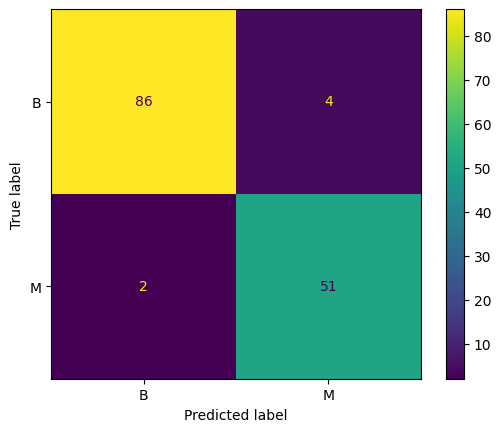

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay,RocCurveDisplay
ConfusionMatrixDisplay.from_estimator(tree_grid,X_test,y_test)

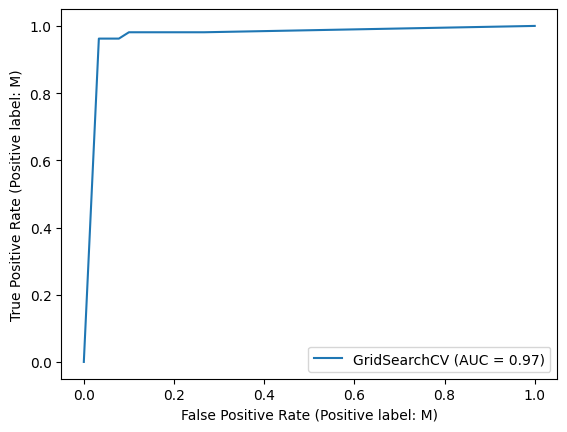

In [ ]:
RocCurveDisplay.from_estimator(tree_grid, X_test,y_test)

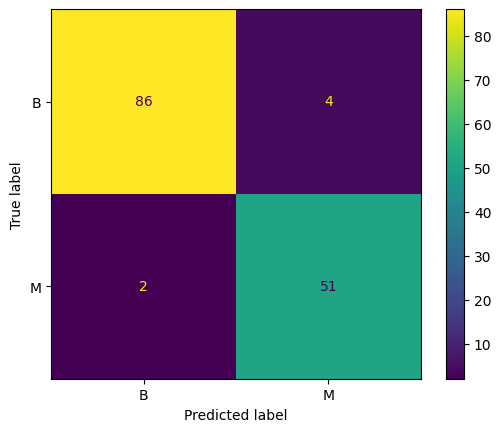

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(tree_grid, X_test, y_test)

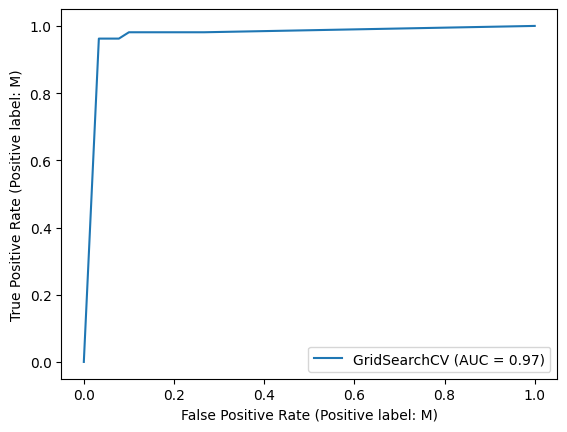

In [ ]:
# roc curve of grid model on test set
from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_estimator(tree_grid, X_test, y_test)